# 18 - LightGBM Production Model

Promotes LightGBM to the deployed production model, replacing
`notebooks/17_final_production_model.ipynb`'s random-forest
configuration - **not because notebook 17 was wrong**, but because the
2026-08-22 live-data refresh flipped the model ranking (see CLAUDE.md's
"Model selection rationale" and notebook 17's own updated conclusion,
cell 16): GBM and LightGBM now both beat random forest's reference and
production configs, and the user explicitly chose to switch to
LightGBM. Notebook 17 is left as-is - a valid, separately-documented
random-forest result, just no longer the deployed one.

This notebook trains exactly `09_lightgbm_model.ipynb`'s configuration
(default-hyperparameter `LGBMRegressor`, notebook 08/09/14's original
feature set) and saves it as the production artifact. **Deliberately
does not include `weekend_weekday_ratio`**: that feature was only ever
tested against random forest (`15_feature_followups_model.ipynb`'s own
scope statement), never against LightGBM/GBM/MLP/Prophet, so shipping it
here unvalidated would contradict this project's own "no speculative
features" convention. Dropping it also retires `models/
weekend_weekday_ratio.csv` and its plumbing from the live inference
path (`inference.py`, `dashboard_common.py`, `scripts/send_daily_email.py`,
`daily_report.py`) - see those files' diffs in this same change.

**A note on categorical encoding, since this is the one real code
difference from notebook 09**: notebook 09 casts categorical columns to
pandas `category` dtype separately for its train and test calls
(`_prepare_features`, cell 9/11 there) - this is *not* a bug. LightGBM's
fitted `Booster` stores each categorical column's fit-time category
values (`pandas_categorical`) and remaps predict-time values onto the
training-time codes by value, not by whatever "position in the current
batch" pandas would otherwise assign - so notebook 09's approach
produced its correct 10.461/17.992 result. This notebook still wraps
that casting in an explicit `FixedCategoryCaster` step
(`src/muenster_bike_forecast/modeling/lightgbm_features.py`) inside the
saved `Pipeline`, for two reasons unrelated to "fixing" notebook 09: (1)
`inference.py`'s live single-row prediction path
(`predict_24h_ahead`) needs the *same* column-count/dtype contract
LightGBM's C++ backend enforces at predict time (a plain, uncast
DataFrame would hard-error, not silently misbehave, per LightGBM's own
category-column-count check) - a bare `LGBMRegressor.predict()` call on
`inference.py`'s output would break; wrapping the cast into the saved
artifact keeps `inference.py` itself fully model-agnostic (unchanged
"any object exposing `.predict`" abstraction). (2) Being explicit about
the fixed category list in this project's own code, rather than relying
solely on an undocumented third-party internal, is more maintainable.
`tests/test_lightgbm_features.py` proves this directly: predicting one
row via a single-row DataFrame is bit-identical to predicting that same
row as part of a larger batch.

## 1. Setup

In [1]:
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from muenster_bike_forecast.modeling.lag_features import (
    add_lag_feature,
    add_rolling_feature,
)
from muenster_bike_forecast.modeling.lightgbm_features import FixedCategoryCaster
from muenster_bike_forecast.modeling.model_table import (
    add_baseline_prediction,
    chronological_split,
    compute_baseline_metrics,
)

MODEL_TABLE_PATH = PROJECT_ROOT / "data" / "raw" / "model_table" / "model_table.csv"
TEST_PERIOD = pd.Timedelta(weeks=8)
RANDOM_STATE = 0

## 2. Load the feature table and add lag/rolling history features

Identical to notebooks 08/09/11/14/15/16/17.

In [2]:
full_df = pd.read_csv(MODEL_TABLE_PATH, parse_dates=["datetime"])
full_df = full_df.sort_values(["station_id", "datetime"]).reset_index(drop=True)
print(
    f"Loaded {len(full_df):,} rows x {full_df.shape[1]} columns "
    f"from {MODEL_TABLE_PATH.relative_to(PROJECT_ROOT)}"
)

LAG_SPECS = {
    "lag_1h": pd.Timedelta(hours=1),
    "lag_1d": pd.Timedelta(days=1),
    "lag_1w": pd.Timedelta(weeks=1),
}
ROLLING_SPECS = {
    "rolling_mean_2h": pd.Timedelta(hours=2),
    "rolling_mean_24h": pd.Timedelta(hours=24),
}

for feature_col, lag in LAG_SPECS.items():
    full_df = add_lag_feature(full_df, lag=lag, feature_col=feature_col)

for feature_col, window in ROLLING_SPECS.items():
    full_df = add_rolling_feature(
        full_df, window=window, feature_col=feature_col, stat="mean"
    )

history_feature_cols = list(LAG_SPECS) + list(ROLLING_SPECS)
full_df = add_baseline_prediction(full_df)

Loaded 2,441,237 rows x 20 columns from data\raw\model_table\model_table.csv


## 3. Chronological split

In [3]:
train_df, test_df, cutoff = chronological_split(full_df, test_period=TEST_PERIOD)
print(f"Chronological cutoff: {cutoff}")
train_labeled = train_df.dropna(subset=["target_total_count"]).copy()
test_df = test_df.copy()
print(f"Train rows with a non-null target: {len(train_labeled):,}   Test rows: {len(test_df):,}")

Chronological cutoff: 2026-06-25 23:45:00


Train rows with a non-null target: 2,247,756   Test rows: 123,671


## 4. Train the production LightGBM model

Notebook 09's exact feature set and hyperparameters (default
`LGBMRegressor` + fixed seed) - **no** `weekend_weekday_ratio`, `hour_dow`,
or `precipitation_bucket` (see the notebook-level note above for why).
The only difference from notebook 09 itself is wrapping the categorical
cast in `FixedCategoryCaster` inside a `Pipeline`, so the saved artifact
is directly usable by `inference.py`'s single-row prediction path.

In [4]:
CATEGORICAL_FEATURES = [
    "station_id",
    "hour",
    "day_of_week",
    "month",
    "is_public_holiday",
    "is_school_holiday",
    "is_lecture_period",
]
NUMERIC_FEATURES = [
    "total_count",
    "weather_air_temperature_c",
    "weather_relative_humidity_pct",
    "weather_precipitation_mm",
    "weather_wind_speed_ms",
    *history_feature_cols,
]
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_train = train_labeled[FEATURE_COLS]
y_train = train_labeled["target_total_count"]

model = Pipeline(
    [
        ("cast_categorical", FixedCategoryCaster(CATEGORICAL_FEATURES)),
        (
            "lgbm",
            LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1),
        ),
    ]
)

_t0 = time.time()
model.fit(X_train, y_train, lgbm__categorical_feature=CATEGORICAL_FEATURES)
fit_seconds = time.time() - _t0
print(f"Model fit on {len(X_train):,} rows in {fit_seconds:.1f}s.")

Model fit on 2,247,756 rows in 6.3s.


## 5. Evaluate against the baseline

In [5]:
test_labeled = test_df.dropna(subset=["target_total_count"]).copy()
X_test = test_labeled[FEATURE_COLS]
test_labeled["final_model_prediction"] = model.predict(X_test)

overall_final = compute_baseline_metrics(
    test_labeled, prediction_col="final_model_prediction"
)
overall_baseline = compute_baseline_metrics(test_labeled, prediction_col="baseline_prediction")

print("Seasonal-naive baseline:", overall_baseline.iloc[0][["mae", "rmse"]].to_dict())
print("Notebook 09 (LightGBM, reference, not retrained here):  MAE 10.461 / RMSE 17.992")
print("This notebook (LightGBM, production Pipeline):         ", overall_final.iloc[0][["mae", "rmse"]].to_dict())

Seasonal-naive baseline: {'mae': 16.661460691733286, 'rmse': 31.11059604863332}
Notebook 09 (LightGBM, reference, not retrained here):  MAE 10.461 / RMSE 17.992
This notebook (LightGBM, production Pipeline):          {'mae': 10.461348948936305, 'rmse': 17.992009807125324}


## 6. Per-station robustness check

Same check notebook 17 ran for random forest: confirm this configuration
doesn't regress badly on any single station, and specifically on the two
previously-flagged stations (`300037405`, `300038855`).

In [6]:
per_station_final = compute_baseline_metrics(
    test_labeled, prediction_col="final_model_prediction", group_col="station_id"
).rename(columns={"mae": "mae_final", "rmse": "rmse_final"})
per_station_baseline = compute_baseline_metrics(
    test_labeled, prediction_col="baseline_prediction", group_col="station_id"
).rename(columns={"mae": "mae_baseline", "rmse": "rmse_baseline"})

per_station = per_station_final.merge(
    per_station_baseline[["group", "mae_baseline", "rmse_baseline"]], on="group"
)
per_station["mae_improvement_pct"] = (
    (per_station["mae_baseline"] - per_station["mae_final"]) / per_station["mae_baseline"] * 100
)
n_improving = int((per_station["mae_final"] < per_station["mae_baseline"]).sum())
print(f"Beats seasonal-naive baseline on {n_improving}/{len(per_station)} stations.")
per_station.sort_values("mae_improvement_pct")

Beats seasonal-naive baseline on 23/23 stations.


,group,mae_final,rmse_final,n_rows,mae_baseline,rmse_baseline,mae_improvement_pct
19,300037936,6.353150,11.723087,5281,7.538724,15.014138,15.726447
9,100053305,7.513935,13.440352,5281,9.111343,17.189262,17.532075
11,300037544,8.352691,12.835181,5281,10.139557,16.113349,17.622722
22,300039331,4.464191,6.212114,5281,5.895664,8.369938,24.280094
15,300037928,3.976490,5.595465,5281,5.333649,7.948792,25.445231
16,300037931,8.363920,13.047116,5281,11.254687,18.099203,25.685006
18,300037933,4.557989,7.032436,5281,6.141450,9.943135,25.783181
13,300037925,4.871329,6.922908,5281,6.974058,10.579748,30.150717
0,100020113,10.445329,15.440940,5281,15.115130,22.403670,30.894874
17,300037932,7.259672,11.336818,5281,10.652528,17.476481,31.850247


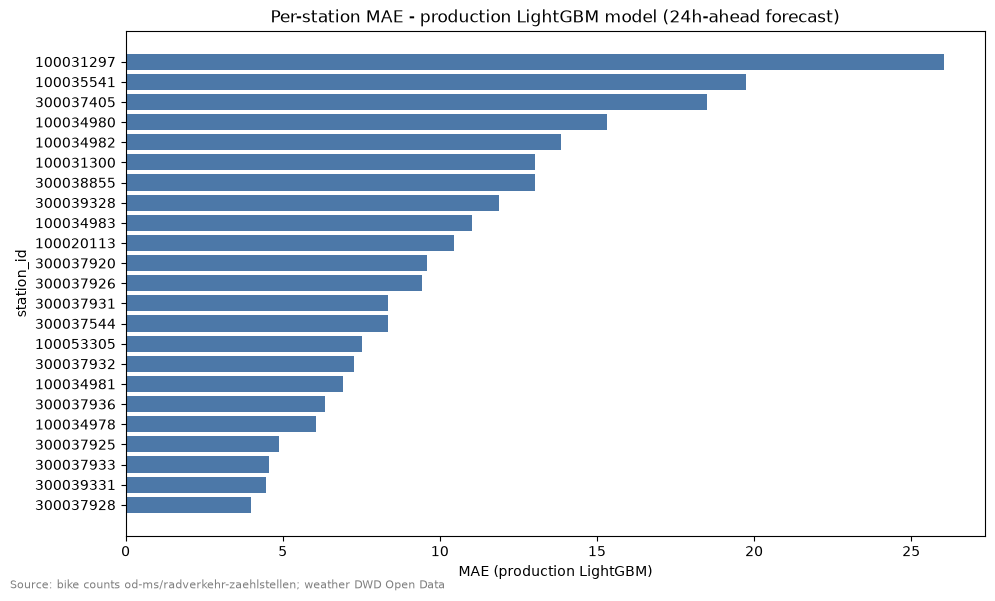

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
plotted = per_station.sort_values("mae_final")
ax.barh(plotted["group"].astype(str), plotted["mae_final"], color="#4C78A8")
ax.set_xlabel("MAE (production LightGBM)")
ax.set_ylabel("station_id")
ax.set_title("Per-station MAE - production LightGBM model (24h-ahead forecast)")
fig.text(
    0.01,
    0.01,
    "Source: bike counts od-ms/radverkehr-zaehlstellen; weather DWD Open Data",
    fontsize=8,
    color="gray",
)
fig.tight_layout()
plt.show()

## 7. Correctness check: single-row vs. batch prediction

Directly proves the categorical-encoding risk this notebook's intro
describes is closed for *this* fitted model, not just in the abstract
unit test (`tests/test_lightgbm_features.py`): predicting one real test
row via a single-row DataFrame (exactly how `inference.predict_24h_ahead`
constructs its input) must equal predicting that same row as part of the
full batch above.

In [8]:
_sample_row = X_test.iloc[[0]]
_single_row_prediction = model.predict(_sample_row)[0]
_batch_prediction = test_labeled["final_model_prediction"].iloc[0]
assert _single_row_prediction == _batch_prediction, (
    f"Single-row prediction ({_single_row_prediction}) does not match "
    f"this row's batch prediction ({_batch_prediction}) - categorical "
    "encoding is not consistent between the two call shapes."
)
print(f"Single-row and batch predictions match exactly: {_single_row_prediction}")

Single-row and batch predictions match exactly: 21.480077461207426


## 8. Save the production model

Serialized to `models/production_lightgbm.joblib` - the sole exception
to the `models/` gitignore rule now (see `.gitignore`), since the
Streamlit dashboard deploys straight from this GitHub repo and needs it
at runtime. `models/production_random_forest.joblib` and `models/
weekend_weekday_ratio.csv` are removed in this same change (see the
notebook-level note above and this change's other file diffs) rather
than kept alongside - see the "Rollback" discussion in this project's
planning notes: keeping the old RF artifact wouldn't have bought a clean
rollback anyway, since `inference.FEATURE_COLS` no longer includes
`weekend_weekday_ratio`, so the old artifact can't be fed by the changed
`inference.py` in isolation regardless of whether the file is still
present.

In [9]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
model_path = MODELS_DIR / "production_lightgbm.joblib"
joblib.dump(model, model_path)
print(
    f"Saved production model to "
    f"{model_path.relative_to(PROJECT_ROOT)} "
    f"({model_path.stat().st_size / 1e6:.1f} MB)"
)

Saved production model to models\production_lightgbm.joblib (0.3 MB)


## 9. Conclusion

**Production configuration**: `LGBMRegressor(random_state=0, verbosity=-1)`
(LightGBM defaults, no tuning beyond the fixed seed) on notebook 08/09/14's
original feature set, wrapped in a `Pipeline` with `FixedCategoryCaster`
for deployable single-row prediction. This reproduces notebook 09's
10.461/17.992 result (see Section 5's printed comparison above) and beats
the seasonal-naive baseline on every station tried (Section 6).

**Why this, not random forest or GBM**: on the current (2026-08-22)
data, LightGBM and GBM are essentially tied (10.461 vs. 10.483 MAE) and
both beat random forest's reference (10.930) and tuned production
(10.728) configurations - see CLAUDE.md's "Model selection rationale"
for the full comparison, including the more aggressively-tuned random-
forest sweep config that narrowly reclaims a lead at a real model-size
cost. The choice between LightGBM and GBM specifically is close to
arbitrary on accuracy grounds; LightGBM was the user's explicit choice.

**What changed in the live-inference path as a result**: `inference.py`
no longer references `weekend_weekday_ratio` (dropped, never validated
against this model class - see the notebook-level note above);
`dashboard_common.py`, `scripts/send_daily_email.py`, and `daily_report.py`
no longer load or thread a ratio table through at all. See CLAUDE.md's
"Model selection rationale" for the decision record.

Data sources: bike counts `od-ms/radverkehr-zaehlstellen` (dl-de/by-2-0);
weather DWD Open Data (CC BY 4.0); NRW school holidays via OpenHolidays
API (ODbL-1.0).